<a href="https://colab.research.google.com/github/duttaaritra794-design/ARITRA_DUTTA/blob/main/SPECIES_STATUS_PREDICTOR_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully

      Species  Population  Temperature  Rainfall  HabitatLoss  Poaching  \
0       Tiger        3200           35      1200           80        70   
1    Elephant       50000           32      1500           50        40   
2  Polar Bear       26000           -5       500           60        20   
3  Blue Whale       15000           12      2000           30        10   
4       Rhino       27000           30      1000           75        80   

       Status  
0  Endangered  
1  Vulnerable  
2  Vulnerable  
3      Stable  
4  Endangered  

Encoded Labels:
['Endangered' 'Stable' 'Vulnerable']

Model Accuracy: 75.00%

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       1.00      1.00      1.00         1
           2       0.50      1.00      0.67         1

    accuracy                           0.75         4
   macro avg       0.83      0.83      0.78      

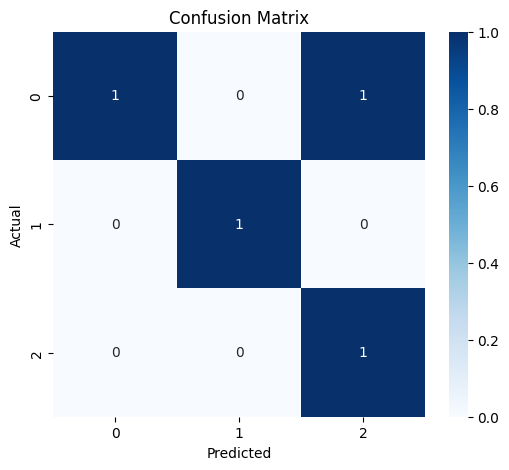

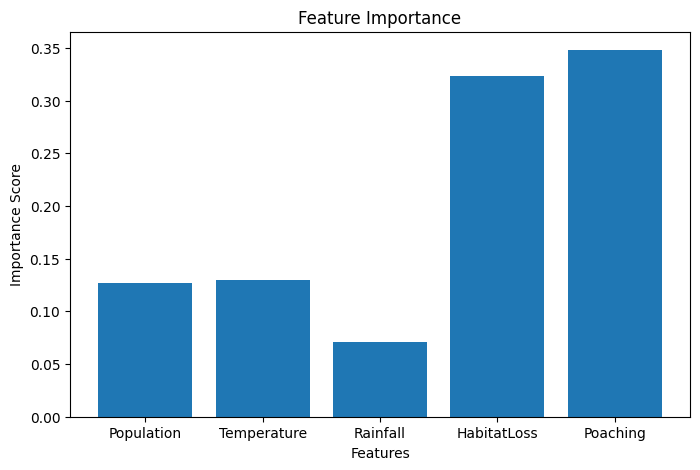


===== Species Survival Prediction =====
Enter Population: 15000
Enter Average Temperature: 20
Enter Rainfall: 20
Enter Habitat Loss %: 70
Enter Poaching Rate: 78

Predicted Species Status: Vulnerable


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

file_path = 'species_data.csv'

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully\n")
print(df.head())
label_encoder = LabelEncoder()
df['Status'] = label_encoder.fit_transform(df['Status'])
print("\nEncoded Labels:")
print(label_encoder.classes_)
X = df[['Population', 'Temperature', 'Rainfall', 'HabitatLoss', 'Poaching']]
y = df['Status']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"\nModel Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_test, predictions))
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.bar(features, importance)
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance Score')

plt.show()


print("\n===== Species Survival Prediction =====")

population = float(input("Enter Population: "))
temperature = float(input("Enter Average Temperature: "))
rainfall = float(input("Enter Rainfall: "))
habitat_loss = float(input("Enter Habitat Loss %: "))
poaching = float(input("Enter Poaching Rate: "))

sample_data = [[
    population,
    temperature,
    rainfall,
    habitat_loss,
    poaching
]]

prediction = model.predict(sample_data)

result = label_encoder.inverse_transform(prediction)

print(f"\nPredicted Species Status: {result[0]}")